In [1]:
import ctypes
import numpy as np

lib = ctypes.CDLL("./libmc.so")

lib.mc_harmonic.argtypes = [
    ctypes.c_int,
    ctypes.c_double,
    np.ctypeslib.ndpointer(dtype=np.float64)
]

lib.mc_harmonic.restype = None

x = np.zeros(10000, dtype=np.float64, order='C')

lib.mc_harmonic(10000, 2.0, x)

print(x)

[1.000e+00 2.000e+00 3.000e+00 ... 9.998e+03 9.999e+03 1.000e+04]


In [5]:
import numpy as np
import mymod2

#x = np.empty(100)
# x = mymod2.mc_harmonic(100, 2.0)
# x

In [19]:
x

array([  1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.,  10.,  11.,
        12.,  13.,  14.,  15.,  16.,  17.,  18.,  19.,  20.,  21.,  22.,
        23.,  24.,  25.,  26.,  27.,  28.,  29.,  30.,  31.,  32.,  33.,
        34.,  35.,  36.,  37.,  38.,  39.,  40.,  41.,  42.,  43.,  44.,
        45.,  46.,  47.,  48.,  49.,  50.,  51.,  52.,  53.,  54.,  55.,
        56.,  57.,  58.,  59.,  60.,  61.,  62.,  63.,  64.,  65.,  66.,
        67.,  68.,  69.,  70.,  71.,  72.,  73.,  74.,  75.,  76.,  77.,
        78.,  79.,  80.,  81.,  82.,  83.,  84.,  85.,  86.,  87.,  88.,
        89.,  90.,  91.,  92.,  93.,  94.,  95.,  96.,  97.,  98.,  99.,
       100.])

In [17]:
import mymod2
print(mymod2.mc_harmonic.__doc__)

x_arr = mc_harmonic(n,k)

Wrapper for ``mc_harmonic``.

Parameters
----------
n : input int
k : input float

Returns
-------
x_arr : rank-1 array('d') with bounds (n)



In [32]:
import mymcmod
print(mymcmod.mclib_mod.mc_harmonic.__doc__)

x_arr,e_arr = mc_harmonic(totstep,eqstep,nout,k)

Wrapper for ``mc_harmonic``.

Parameters
----------
totstep : input int
eqstep : input int
nout : input int
k : input float

Returns
-------
x_arr : rank-1 array('d') with bounds (nout)
e_arr : rank-1 array('d') with bounds (nout)



In [35]:
import numpy as np
import matplotlib.pyplot as plt
import mymcmod5

mclib = mymcmod5

totstep = 1000000
eqstep = 10000
nout = totstep - eqstep
k = 2.0

x, nrg = mclib.mc_harmonic(totstep,eqstep,nout,k)

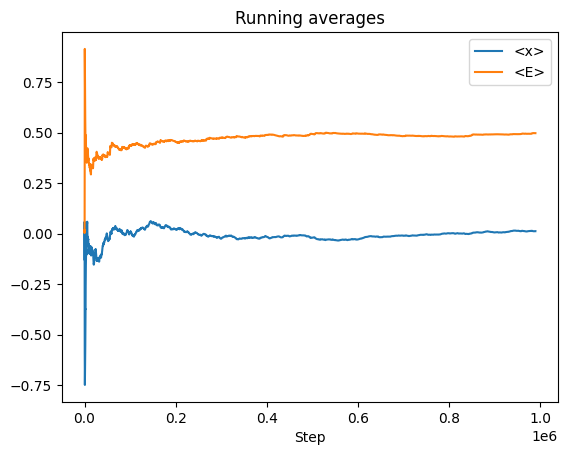

In [36]:
# cumulative averages
step = np.arange(1, len(x)+1)
avx = np.cumsum(x) / step
avnrg = np.cumsum(nrg) / step

plt.figure()
plt.plot(step, avx, label="<x>")
plt.plot(step, avnrg, label="<E>")
plt.legend()
plt.xlabel("Step")
plt.title("Running averages")
plt.show()

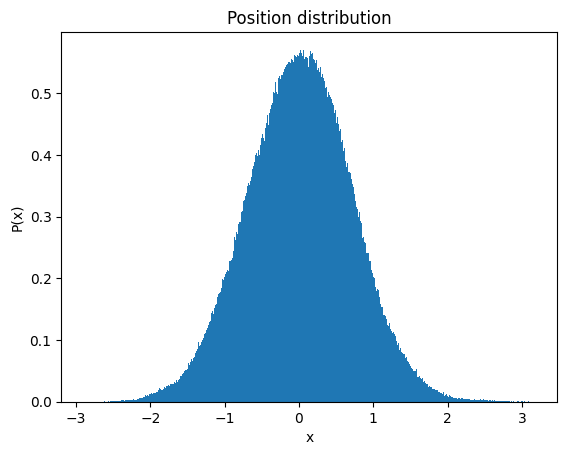

In [37]:
plt.figure()
plt.hist(x, bins=500, density=True)
plt.xlabel("x")
plt.ylabel("P(x)")
plt.title("Position distribution")
plt.show()

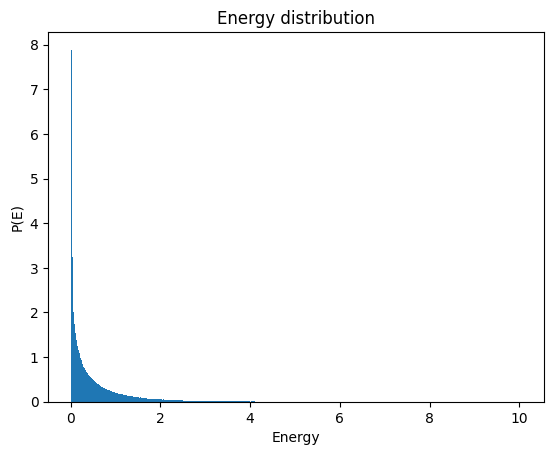

In [38]:
plt.figure()
plt.hist(nrg, bins=500, density=True)
plt.xlabel("Energy")
plt.ylabel("P(E)")
plt.title("Energy distribution")
plt.show()

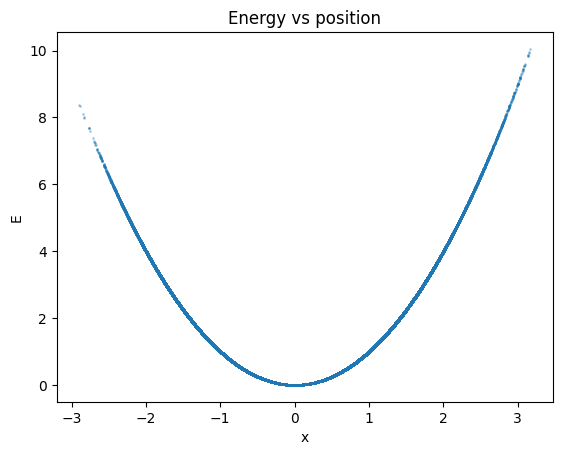

In [39]:
plt.figure()
plt.scatter(x, nrg, s=1, alpha=0.3)
plt.xlabel("x")
plt.ylabel("E")
plt.title("Energy vs position")
plt.show()

In [41]:
mclib.mc_test(10, 2.0)

array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.])